In [1]:
import yaml
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Configuration and paths
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# maf=1e-3
# n = !wc -l $eur_samples_path
# n_eur = int(n[0].split(' ')[0])
# mac = maf*(2*n_eur)

mac = 20

config_path = "/home/dnanexus/ukbgym/config_wgs.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Read the variant consequence configuration
records = []
for group, consequences in config["variant_consequences"].items():
    for consequence in consequences:
        records.append({'variant_class': group, 'vep_consequence': consequence})
var_cons = pl.DataFrame(records)


# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records)
all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i64
"""plof_consequences""","""consequence_frameshift_variant""","""#E31A1C""","""VEP Frameshift""",1
"""plof_consequences""","""consequence_stop_gained""","""#FB9A99""","""VEP Stop Gained""",1
"""plof_consequences""","""consequence_splice_donor_varia…","""#6A1B9A""","""VEP Splice Donor""",1
"""plof_consequences""","""consequence_splice_acceptor_va…","""#AB47BC""","""VEP Splice Acceptor""",1
"""plof_consequences""","""consequence_start_lost""","""#E65100""","""VEP Start Lost""",1
…,…,…,…,…
"""vep_consequences""","""consequence_splice_acceptor_va…","""#AB47BC""","""VEP Splice Acceptor""",1
"""vep_consequences""","""consequence_start_lost""","""#E65100""","""VEP Start Lost""",1
"""vep_consequences""","""consequence_stop_lost""","""#FFB300""","""VEP Stop Lost""",1


In [3]:
# anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass352genes_olink371genes_annotated_251205.parquet")
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass352genes_olink371genes_annotated_251205_fillna.parquet")

min_range = -2000
max_range = +0

anno = (
    anno
    .filter(
        # Choose CDS
        (pl.col('vep_cds_relaxed')==True)
        # ((pl.col('vep_cds_relaxed')==True) | (pl.col('mane_cds')==True)) &
        # (pl.col('non_mane_cds')==False) &

        # Choose non CDS only
        # ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)) &

        # Choose VEP consequence
        # (pl.col('consequence_missense_variant') == True) &
        # (pl.col('consequence_synonymous_variant') == True) &
        # (pl.col('consequence_5_prime_utr_variant') == True) &
        # (pl.col('consequence_upstream_gene_variant') == True) &
        # (pl.col('consequence_downstream_gene_variant') == True) &
        # (pl.col('consequence_intron_variant') == True) &

        # Choose MobiDB region
        # (pl.col('mobi_lip_full') == True) &
        # (pl.col('mobi_disorder_full') == True) &

        # Custom variant class filter
        # filter_expression &

        # Choose regulatory region
        # (pl.col('encode_eh_pr') == True) &
        # (pl.col('encode_all_tf') == True) &
        
        # Proximity to TSS
        # (pl.col('dist_to_tss') >= min_range) &
        # (pl.col('dist_to_tss') <= max_range) &

        # Only SNPs
        # (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .with_columns(
        core_promoter = pl.col('dist_to_tss').abs() <= 50,
        encode_annotated = pl.col('not_in_encode') == False,
        encode_eh_pr = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pls', 'encode_pels', 'encode_dels']),
        encode_all_tf = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_tf', 'encode_ca_tf']),
    )
    .with_columns(
        loftee_disorder = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'mobi_curated_disorder_priority']),
        loftee_lip = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'mobi_lip_full']),
        loftee_ted = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'ted_domain']),
        loftee_low_complexity = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'low_complexity_domain']),
    )
)

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

anno = (
    anno
    .select(
        set(['id', 'region', 'tss', 'strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

consequence_stop_lost,five_prime_utr_variant_consequence_uaug_lost,five_prime_utr_variant_consequence_ustop_lost,gene_length,gene_name,encode_dels,loftee_disorder,abexp_min,encode_pls,five_prime_utr_variant_consequence_uaug_gained,mobi_curated_disorder_priority,consequence_missense_variant,promoterai_abs,loftee_ted,am_pathogenicity,five_prime_utr_variant_consequence_ustop_gained,loftee_low_complexity,strand,esmscoremissense,low_complexity_domain,verphylop,consequence_splice_donor_variant,consequence_start_lost,consequence_splice_acceptor_variant,gpn_score,absplice_dna_max,promoterai,encode_pels,gpn_star_llr_calibrated_mean,encode_eh_pr,ted_domain,encode_tf,tss,region,consequence_frameshift_variant,consequence_stop_gained,mobi_lip_full,pangolin_score,cadd_raw,loftee_lc,abexp_abs_max,absplice2_max,dist_to_tss,id,delta_score,score_pai3d,loftee_hc,consequence_synonymous_variant,loftee_lip,encode_ca_tf
i32,u8,u8,i64,str,bool,bool,f32,bool,u8,bool,i32,f32,bool,f32,u8,bool,str,f32,bool,f32,i32,i32,i32,f32,f32,f32,bool,f32,bool,bool,bool,i64,str,i32,i32,bool,f32,f32,i8,f32,f32,i64,str,f32,f32,i8,i32,bool,bool
0,0,0,26121,"""PLEKHO2""",true,false,-1.997105,false,0,false,1,0.0,false,0.6981,0,false,"""1""",-6.781,false,9.133,0,0,0,-12.04,0.29,0.0,false,-9.52998,true,false,false,64841882,"""ENSG00000241839""",0,0,true,0.82,6.585388,0,1.997105,0.531172,18116,"""chr15:64859998:G:C""",0.87,0.626882,0,0,false,false
0,0,0,83994,"""KDM5B""",false,false,-0.049098,false,0,true,1,0.0028,false,0.0911,0,false,"""-1""",-3.949,true,4.968,0,0,0,-8.92,0.001,-0.0028,false,-6.822783,false,false,false,202808487,"""ENSG00000117139""",0,0,true,0.0,2.497457,0,0.049098,0.000074,78602,"""chr1:202729885:A:T""",0.0,0.602516,0,0,false,false
0,0,0,9354,"""ACRV1""",false,false,-0.078567,false,0,false,1,0.0,false,0.9957,0,false,"""-1""",-12.142,false,3.389,0,0,0,-6.64,0.003,0.0,false,-7.618337,false,true,false,125680874,"""ENSG00000134940""",0,0,false,0.0,4.886163,0,0.078567,0.000395,8246,"""chr11:125672628:A:G""",0.0,0.758137,0,0,false,false
0,0,0,83994,"""KDM5B""",true,false,-0.026393,false,0,false,1,0.0,false,0.0651,0,false,"""-1""",-3.762,false,-0.317,0,0,0,-2.59,0.003,0.0,false,-1.582607,true,false,false,202808487,"""ENSG00000117139""",0,0,false,0.0,1.024761,0,0.026393,0.000341,65687,"""chr1:202742800:C:T""",0.0,0.254022,0,0,false,false
0,0,0,83994,"""KDM5B""",false,false,-0.07843,false,0,true,1,0.0,false,0.0902,0,false,"""-1""",-3.944,false,2.362,0,0,0,-5.7,0.003,0.0,false,-3.622938,false,false,false,202808487,"""ENSG00000117139""",0,0,false,0.0,2.466337,0,0.07843,0.000369,72937,"""chr1:202735550:A:G""",0.0,0.412907,0,0,false,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0,0,0,41554,"""HDAC1""",true,false,0.0,false,0,false,0,0.0,true,0.0,0,false,"""1""",0.0,false,0.129,0,0,0,-1.41,0.0,0.0,false,null,true,true,false,32292082,"""ENSG00000116478""",1,0,false,0.0,0.28051,0,0.0,0.0,24674,"""chr1:32316756:C:CG""",0.0,0.0,1,0,false,false
0,0,0,202697,"""RTTN""",false,false,0.0,false,0,false,0,0.0,false,0.0,0,false,"""-1""",0.0,false,0.129,0,0,0,-1.41,0.0,0.0,false,null,false,false,false,70205726,"""ENSG00000176225""",1,0,false,0.0,0.28051,0,0.0,0.0,184988,"""chr18:70020738:CAG:C""",0.0,0.0,1,0,false,false
0,0,0,54681,"""CHEK2""",false,false,0.0,false,0,false,0,0.0,false,0.0,0,false,"""-1""",0.0,false,0.129,0,0,0,-1.41,0.0,0.0,false,null,false,true,false,28742422,"""ENSG00000183765""",0,0,false,0.0,0.28051,0,0.0,0.0,38886,"""chr22:28703536:CAAA:C""",0.0,0.0,0,0,false,false


In [4]:
selected_annos = anno_config_df.filter(
    # pl.col('category').is_in(['vep_consequences']) # VEP CDS consequences
    # pl.col('category').is_in(['plof_consequences']) # VEP plof consequences
    # (pl.col('category').is_in(['plof', 'missense', 'genetic_diversity', 'conservation', 'splicing'])) # CDS
    # (pl.col('category').is_in(['missense', 'genetic_diversity', 'conservation'])) # missense
    # (pl.col('category').is_in(['protein_domains'])) # protein domains
    (pl.col('category').is_in(['loftee_protein_domains'])) # protein domains
    # (pl.col('category').is_in(['splicing', 'genetic_diversity', 'conservation'])) # synonymous

    # (pl.col('category').is_in(['splicing', 'conservation', 'regulatory_nondir', 'genetic_diversity'])) # non coding
    # (pl.col('category').is_in(['encode_regions'])) # encode regions
    # (pl.col('category').is_in(['encode_custom'])) # encode regions custom
    # (pl.col('category').is_in(['conservation', 'regulatory_nondir', 'genetic_diversity'])) # 5UTR
)['annotation'].to_list()

melted_anno = (
    anno

    .select(
        set(['id', 'region']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )
)

melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr15:64859998:G:C""","""ENSG00000241839""","""loftee_disorder""",0.0
"""chr1:202729885:A:T""","""ENSG00000117139""","""loftee_disorder""",0.0
"""chr11:125672628:A:G""","""ENSG00000134940""","""loftee_disorder""",0.0
"""chr1:202742800:C:T""","""ENSG00000117139""","""loftee_disorder""",0.0
"""chr1:202735550:A:G""","""ENSG00000117139""","""loftee_disorder""",0.0
…,…,…,…
"""chr1:32316756:C:CG""","""ENSG00000116478""","""loftee_low_complexity""",0.0
"""chr18:70020738:CAG:C""","""ENSG00000176225""","""loftee_low_complexity""",0.0
"""chr22:28703536:CAAA:C""","""ENSG00000183765""","""loftee_low_complexity""",0.0


In [5]:
appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_genebass1e6_PRScorr_with_percentiles.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)
# unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()

In [6]:
# Get gene trait associations

plof = pl.read_parquet('/home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie.parquet').with_columns(
    phenotype = (pl.col('trait') + '_int'),
    region = pl.col('gene_id'),
    rvat_pval = (10** -pl.col("neg_log10p")),
).filter(
    (pl.col('trait_type') == 'quantitative')
)

loftee_corr = pl.read_parquet("/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_wgs_EUR_genebass1e6_maf1e3_snp_consistent.parquet")

gene_trait_df = loftee_corr.join(plof[['region', 'phenotype', 'beta', 'rvat_pval']], on=['region', 'phenotype'], how='inner').filter(
    pl.col('loftee_corr')*pl.col('beta') > 0
).with_columns(
    corr_dir = pl.col('loftee_corr')/pl.col('loftee_corr').abs()
)
gene_trait_df

region,gene_name,phenotype,loftee_corr,n_variants,beta,rvat_pval,corr_dir
str,str,str,f64,u64,f64,f64,f64
"""ENSG00000116183""","""PAPPA2""","""arm_fatfree_mass_right_int""",-0.014747,82603,-0.195409,9.1637e-8,-1.0
"""ENSG00000129083""","""COPB1""","""arm_fatfree_mass_right_int""",-0.014338,13594,-0.397279,0.006626,-1.0
"""ENSG00000100578""","""KIAA0586""","""arm_fatfree_mass_right_int""",-0.010787,28541,-0.058463,0.000305,-1.0
"""ENSG00000157766""","""ACAN""","""arm_fatfree_mass_right_int""",-0.036259,20244,-0.436618,6.0395e-11,-1.0
"""ENSG00000140443""","""IGF1R""","""arm_fatfree_mass_right_int""",-0.013644,82469,-0.412619,2.8609e-8,-1.0
…,…,…,…,…,…,…,…
"""ENSG00000112077""","""RHAG""","""reticulocyte_count_int""",0.033239,9849,0.952411,1.8038e-41,1.0
"""ENSG00000029534""","""ANK1""","""reticulocyte_count_int""",0.02685,54620,0.656849,2.1682e-10,1.0
"""ENSG00000197969""","""VPS13A""","""reticulocyte_count_int""",0.003971,55477,0.176348,2.1188e-7,1.0


In [7]:
gene_trait_df['region'].n_unique(), gene_trait_df.shape[0]

(352, 1176)

In [8]:
# --- 1. Lazily prepare the filter keys ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())


# --- 2. Build the main lazy query plan step-by-step ---
# Start by filtering 'appv', then join everything together. Every operation returns another LazyFrame.
final_lazy_plan = (
    # A. Use a semi join for efficient filtering (more memory-safe than 'is_in')
    appv
    .join(anno_ids_lazy, on="id", how="semi")

    # B. Join the other two dataframes
    .join(
        melted_anno.lazy().drop([c for c in melted_anno.columns if 'is_nan' in c]),
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )

    # C. Apply the ranking (window function) lazily
    .with_columns(
        pl.col(c)
        .rank("average")
        .over(["region", "phenotype", "annotation"])
        .alias(f"{c}_rank")
        for c in ['annotation_score', 'mean_pheno_value']
    )

    # D. Apply the group_by and aggregation lazily
    .group_by(["region", "gene_name", "phenotype", "annotation"])
    .agg(
        n_variants = pl.col("id").count(),
        correlation = pl.corr("annotation_score_rank", "mean_pheno_value_rank", propagate_nans=True)
    )
)

# --- 3. Execute the ENTIRE plan at once ---
# This is the ONLY time data is computed. The streaming engine handles the whole complex query in memory-safe chunks.
print("Executing the full lazy plan with the streaming engine...")
correlation_df = final_lazy_plan.collect(engine='streaming')

Executing the full lazy plan with the streaming engine...


In [9]:
# --- 4. Join with beta directions and annotation directions ---
correlation_df = (
    correlation_df
    .select(["region", "gene_name", "phenotype", "annotation", "n_variants", "correlation"])
    .join(
        anno_config_df.drop('category').unique(), on='annotation'
    )
    .join(
        gene_trait_df[['region', 'phenotype', 'corr_dir']], on=['region', 'phenotype']
    )
    .with_columns(
        corr_beta = pl.col('correlation')*pl.col('corr_dir')*pl.col('annotation_dir')
    )
)
print("Final DataFrame shape:", correlation_df.shape)
correlation_df

Final DataFrame shape: (4704, 11)


region,gene_name,phenotype,annotation,n_variants,correlation,color,label,annotation_dir,corr_dir,corr_beta
str,str,str,str,u64,f64,str,str,i64,f64,f64
"""ENSG00000127585""","""FBXL16""","""leg_fat_mass_right_int""","""loftee_ted""",258,0.088361,"""#2E8B57""","""Structured Domain""",1,1.0,0.088361
"""ENSG00000196739""","""COL27A1""","""standing_height_int""","""loftee_lip""",1665,-0.092023,"""#1E90FF""","""LIP domain""",1,-1.0,0.092023
"""ENSG00000116183""","""PAPPA2""","""arm_predicted_mass_left_int""","""loftee_ted""",1254,-0.08301,"""#2E8B57""","""Structured Domain""",1,-1.0,0.08301
"""ENSG00000158158""","""CNNM4""","""calcium_int""","""loftee_disorder""",524,NaN,"""#E31A1C""","""Disordered domain""",1,1.0,NaN
"""ENSG00000008710""","""PKD1""","""urea_int""","""loftee_low_complexity""",5574,-0.015988,"""#FF9933""","""Low complexity domain""",1,1.0,-0.015988
…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000183765""","""CHEK2""","""platelet_distribution_width_in…","""loftee_low_complexity""",473,0.026343,"""#FF9933""","""Low complexity domain""",1,1.0,0.026343
"""ENSG00000145703""","""IQGAP2""","""mean_platelet_thrombocyte_volu…","""loftee_lip""",1097,0.101616,"""#1E90FF""","""LIP domain""",1,1.0,0.101616
"""ENSG00000198146""","""ZNF770""","""shbg_int""","""loftee_ted""",390,0.256393,"""#2E8B57""","""Structured Domain""",1,1.0,0.256393


In [10]:

consistent_gt = (
    correlation_df
    .drop_nulls().drop_nans()
    .group_by(['region', 'gene_name', 'phenotype'])
    .agg(n_annotations = pl.len())
    .sort('n_annotations', descending=True)
    .filter(pl.col('n_annotations') == correlation_df['annotation'].n_unique())
)

# filt_corr_df = correlation_df.filter(pl.col("n_variants") > 10)  # Select genes with more than 10 variants
filt_corr_df = correlation_df.filter(pl.col("n_variants") > 100)
filt_corr_df = filt_corr_df.join(consistent_gt, on=['region', 'gene_name', 'phenotype'], how='inner')
filt_corr_df

region,gene_name,phenotype,annotation,n_variants,correlation,color,label,annotation_dir,corr_dir,corr_beta,n_annotations
str,str,str,str,u64,f64,str,str,i64,f64,f64,u64
"""ENSG00000110934""","""BIN2""","""mean_platelet_thrombocyte_volu…","""loftee_lip""",349,-0.181504,"""#1E90FF""","""LIP domain""",1,-1.0,0.181504,4
"""ENSG00000169047""","""IRS1""","""forced_expiratory_volume_in_1s…","""loftee_ted""",801,-0.100667,"""#2E8B57""","""Structured Domain""",1,-1.0,0.100667,4
"""ENSG00000012048""","""BRCA1""","""mothers_age_at_death_int""","""loftee_ted""",937,-0.042916,"""#2E8B57""","""Structured Domain""",1,-1.0,0.042916,4
"""ENSG00000169047""","""IRS1""","""forced_vital_capacity_fvc_best…","""loftee_ted""",856,-0.055373,"""#2E8B57""","""Structured Domain""",1,-1.0,0.055373,4
"""ENSG00000157766""","""ACAN""","""arm_fatfree_mass_left_int""","""loftee_lip""",1635,-0.103133,"""#1E90FF""","""LIP domain""",1,-1.0,0.103133,4
…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000169174""","""PCSK9""","""direct_bilirubin_int""","""loftee_low_complexity""",584,0.004607,"""#FF9933""","""Low complexity domain""",1,1.0,0.004607,4
"""ENSG00000169047""","""IRS1""","""arm_predicted_mass_left_int""","""loftee_disorder""",952,-0.015026,"""#E31A1C""","""Disordered domain""",1,-1.0,0.015026,4
"""ENSG00000183765""","""CHEK2""","""platelet_crit_int""","""loftee_low_complexity""",473,0.019833,"""#FF9933""","""Low complexity domain""",1,1.0,0.019833,4


In [11]:
annos_w_inconsistent_assocs = (
    filt_corr_df
    .drop_nulls().drop_nans()
    .select(['region', 'gene_name', 'phenotype', 'annotation'])
    .group_by('annotation')
    .agg(n_associations = pl.len())
    .select('n_associations').n_unique()
) - 1

print(f"Annotations with inconsistent associations: {annos_w_inconsistent_assocs}")

# Check if the variant counts are consistent within each (region, phenotype) pair
var_inconsistent = (
    filt_corr_df
    .drop_nans()
    .drop_nulls()
    .group_by(["region", "phenotype"])
    .agg(pl.col("n_variants").n_unique().alias("n_variants_unique"))
    .filter(pl.col("n_variants_unique") > 1)
)
print(f"Inconsistent (region, phenotype) pairs: {var_inconsistent.shape[0]}")

Annotations with inconsistent associations: 0
Inconsistent (region, phenotype) pairs: 0


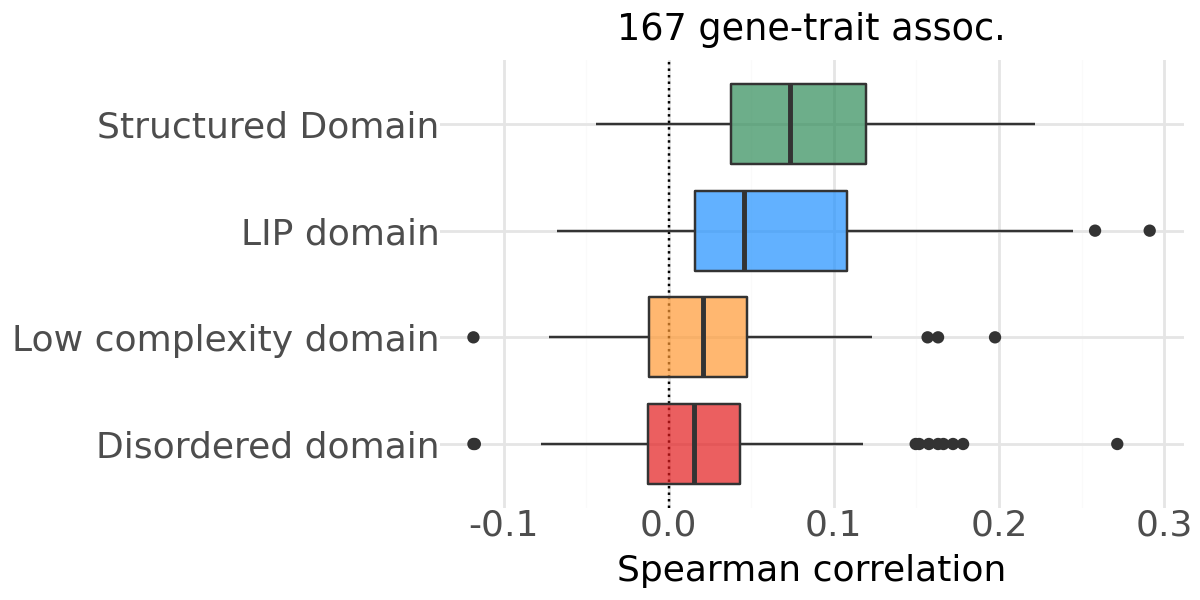

In [17]:
# Prepare for plotting
med_df = filt_corr_df.drop_nans().group_by("annotation").agg(
    median_corr_beta = pl.col("corr_beta").median(),
)

corr_pd = med_df.join(filt_corr_df, on='annotation').to_pandas()

corr_pd['label'] = pd.Categorical(
    corr_pd['label'],
    categories=corr_pd.sort_values('median_corr_beta', ascending=True)['label'].unique(),
    ordered=True
)

color_dict = dict(zip(corr_pd['annotation'], corr_pd['color']))

# Plot
(
    ggplot(corr_pd, aes(x="label", y="corr_beta", fill="annotation"))
    + geom_hline(aes(yintercept=0), color='black', linetype='dotted')
    + geom_boxplot(alpha=0.7)
    + theme_minimal()
    + scale_fill_manual(values=color_dict)
    + labs(
        x="",
        y="Spearman correlation",
        title=f"{corr_pd[['region', 'phenotype']].drop_duplicates().shape[0]} gene-trait assoc."
        # \nGene body ±5kb"
        # \n VEP CDS variants"
        # \n Disorder region missense variants"
        # \n{variant_class} variants"
        # \nTSS [{min_range}bp, {max_range}bp]"
    )
    + coord_flip()
    + theme(
        figure_size=(6, 3),
        legend_position="none",
        # axis_text_x=element_text(rotation=45, hjust=1),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [14]:
med_df.sort('median_corr_beta')

annotation,median_corr_beta
str,f64
"""loftee_disorder""",0.015026
"""loftee_low_complexity""",0.020781
"""loftee_lip""",0.045846
"""loftee_ted""",0.073327


In [15]:
import itertools
from scipy.stats import wilcoxon

annotations = filt_corr_df.select(pl.col("annotation")).unique().to_series().to_list()
pairs = list(itertools.combinations(annotations, 2))

results = []
for a, b in pairs:
    # Subset to same gene-trait pairs where both VSMs have values
    df_a = filt_corr_df.filter(pl.col("annotation") == a).select(["region", "phenotype", "corr_beta"])
    df_b = filt_corr_df.filter(pl.col("annotation") == b).select(["region", "phenotype", "corr_beta"])

    merged = df_a.join(df_b, on=["region", "phenotype"], how="inner", suffix="_b")

    if merged.height > 0:
        stat, pval = wilcoxon(merged["corr_beta"].to_numpy(), merged["corr_beta_b"].to_numpy(), alternative="two-sided")
        results.append((a, b, merged.height, stat, pval))

# Make results dataframe
stats_df = pl.DataFrame(
    results,
    schema=["VSM_A", "VSM_B", "N_pairs", "W_stat", "pval_raw"]
)

stats_df.filter(pl.col("pval_raw") < 0.05).sort("pval_raw")
# stats_df.sort("pval_raw")

/tmp/ipykernel_178900/1012804157.py:20: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.


VSM_A,VSM_B,N_pairs,W_stat,pval_raw
str,str,i64,f64,f64
"""loftee_ted""","""loftee_disorder""",167,1928.0,1.9924e-15
"""loftee_disorder""","""loftee_lip""",167,1734.0,6.1448e-14
"""loftee_low_complexity""","""loftee_lip""",167,1932.0,2.0153e-13
"""loftee_low_complexity""","""loftee_ted""",167,2397.0,4.4507e-13
"""loftee_ted""","""loftee_lip""",167,5564.0,0.0205


In [16]:
stats_df.filter(
    (pl.col('VSM_A') == 'absplice2_max') | (pl.col('VSM_B') == 'absplice2_max')
)

VSM_A,VSM_B,N_pairs,W_stat,pval_raw
str,str,i64,f64,f64
